# 📊 Exploratory Data Analysis (EDA)
---

L’analyse exploratoire des données (EDA) a pour objectif de **comprendre les relations entre les investissements publicitaires et les ventes** à l’aide de visualisations et d’analyses statistiques.

Dans cette section, nous allons :
- Analyser la distribution des variables clés
- Étudier les relations entre chaque canal publicitaire et les ventes
- Identifier les corrélations entre les variables
- Détecter des tendances ou patterns pouvant influencer la modélisation

Cette étape est essentielle pour **valider les hypothèses**, guider le choix du modèle et interpréter les résultats de manière pertinente.

## 📦 Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

## 📂 Chargement du dataset nettoyé

In [4]:
df =pd.read_csv("../data/processed/advertising_cleaned.csv")
print (" ✅ Dataset chargé avec succès!")

 ✅ Dataset chargé avec succès!


## 🔍 Statistiques descriptives du Dataset

In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


### 📊 Synthèse descriptive par variable

#### 📺 TV
- Le budget publicitaire TV présente la **plus forte moyenne d’investissement** (147.0) et une **variabilité élevée** (écart-type ≈ 85.9), indiquant que certaines campagnes investissent massivement tandis que d’autres beaucoup moins.  
Cette large dispersion suggère que la publicité TV pourrait avoir un **impact significatif sur les ventes**, notamment aux niveaux d’investissement élevés.



#### 📻 Radio
- Le budget Radio affiche une moyenne plus modérée (23.3) avec une **variabilité plus faible** que la TV.  
Les investissements radio sont plus concentrés autour de la moyenne, ce qui laisse penser à un canal **plus stable et potentiellement complémentaire** aux autres médias pour influencer les ventes.



#### 📰 Newspaper
- Le budget Newspaper présente une **dispersion importante** (écart-type ≈ 21.8) et une distribution plus asymétrique, avec quelques investissements très élevés (max = 114).  
Cela peut indiquer un canal **moins systématique**, dont l’impact sur les ventes pourrait être **plus variable ou moins prévisible**.



#### 💰 Sales
- Les ventes ont une moyenne de 15.1 avec une dispersion modérée, ce qui indique une **variabilité naturelle des performances commerciales**.  
La distribution des ventes semble suffisamment étendue pour permettre l’identification de **relations significatives avec les investissements publicitaires**.



#### 🔎 Conclusion générale
Les différences de dispersion et de niveaux d’investissement entre les canaux suggèrent que **tous les médias n’ont probablement pas le même impact sur les ventes**.  
Cette analyse descriptive constitue une base solide pour l’EDA bivariée et la régression linéaire, qui permettront de **quantifier précisément l’influence de chaque canal publicitaire**.


## 📈 Analyse univariée de la variable *Sales*

Nous commençons l’EDA par l’analyse de la distribution des ventes afin de comprendre leur répartition, leur dispersion et leur tendance générale.  
Cette étape permet d’identifier d’éventuelles asymétries ou concentrations de valeurs, utiles pour la suite de l’analyse et la modélisation.


## 📊 Forme de la distribution

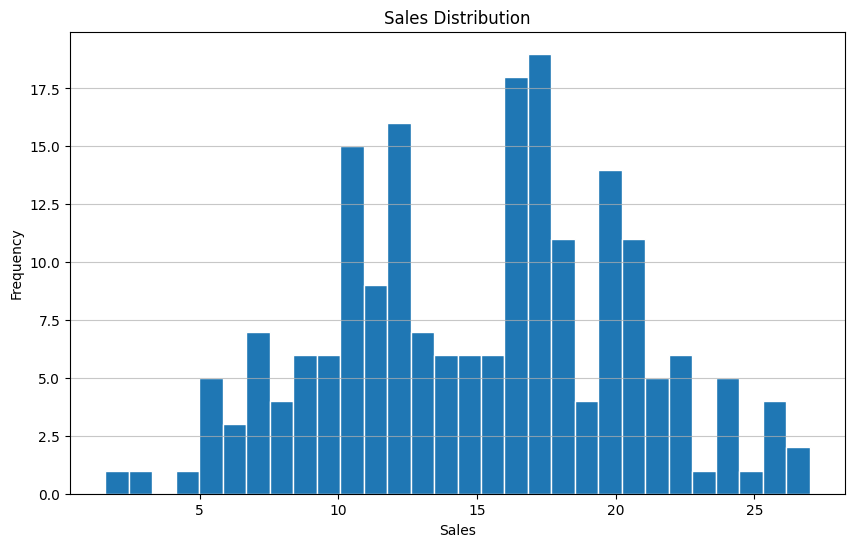

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=30, edgecolor='white')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.7)
plt.show()


### 📝 Interprétation de la distribution des ventes
- L’histogramme des ventes montre une répartition globalement homogène des valeurs, avec une concentration plus marquée autour de la valeur moyenne (environ 15).  

- Les niveaux de ventes les plus fréquents se situent entre 15 et 17,5, ce qui indique que cette zone représente le comportement le plus courant observé dans le dataset.  

Cette cohérence entre la distribution graphique et les statistiques descriptives confirme que la variable *Sales* est bien structurée et adaptée à l’analyse des relations avec les investissements publicitaires.


## 📦 Dispersion et les valeurs extrêmes

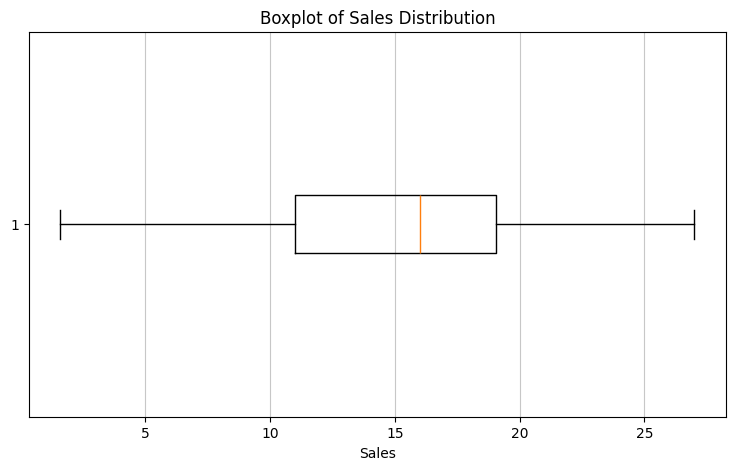

In [7]:
plt.figure(figsize=(9, 5))
plt.boxplot(df['Sales'], vert=False)
plt.title("Boxplot of Sales Distribution")
plt.xlabel("Sales")
plt.grid(axis='x', alpha=0.7)
plt.show()

#### 📝 Interprétation du boxplot des ventes

- Le boxplot résume la distribution des ventes de manière synthétique.  

- La ligne située au centre de la boîte représente la **médiane des ventes**, tandis que la boîte correspond aux **50 % des valeurs centrales** (entre le premier et le troisième quartile).  
Les moustaches indiquent l’étendue normale des ventes et l’absence de points isolés signifie qu’il n’y a **pas de valeurs aberrantes visibles**.

Dans notre cas, la médiane est proche de **15**, la dispersion est raisonnable et aucune valeur extrême n’est détectée.  
Ces observations confirment les conclusions obtenues précédemment à partir de l’histogramme.


## 📈 Analyse des relations entre les investissements publicitaires et les ventes


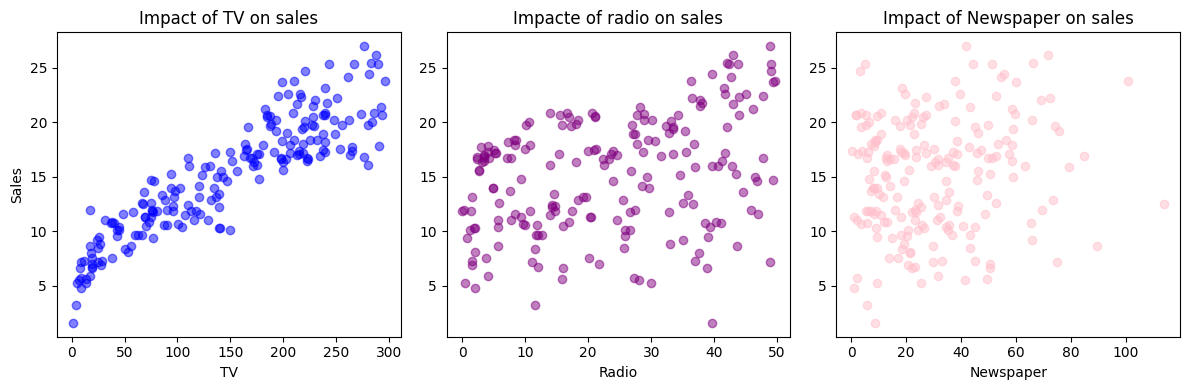

In [8]:
# Créer 3 subplots côte à côte
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Impact of TV on Sales
axs[0].scatter(df['TV'], df['Sales'], color='blue', alpha=0.5)
axs[0].set_title('Impact of TV on sales')
axs[0].set_xlabel('TV')
axs[0].set_ylabel('Sales')

# Impact of Radio on Sales
axs[1].scatter(df['Radio'], df['Sales'], color='purple', alpha=0.5)
axs[1].set_title('Impacte of radio on sales')
axs[1].set_xlabel('Radio')

# Impact of Newspaper on Sales
axs[2].scatter(df['Newspaper'], df['Sales'], color='pink', alpha=0.5)
axs[2].set_title('Impact of Newspaper on sales')
axs[2].set_xlabel('Newspaper')

plt.tight_layout()
plt.show()

Ce code génère **trois graphiques de dispersion (scatter plots)**  
Chaque graphique représente la relation entre un **canal publicitaire** (TV, Radio, Newspaper) et les **ventes**.

- Chaque point correspond à une observation du dataset
- L’axe X représente le budget investi dans un canal publicitaire
- L’axe Y représente les ventes réalisées

Ces graphiques permettent de **visualiser l’impact potentiel de chaque canal publicitaire sur les ventes** et d’identifier d’éventuelles tendances ou relations linéaires.

#### 🧠 Interprétation

- **TV vs Sales** : on observe une tendance croissante claire, indiquant qu’une augmentation du budget TV est généralement associée à une hausse des ventes.

- **Radio vs Sales** : la relation est positive mais plus dispersée, suggérant un impact réel mais moins fort que la TV.

- **Newspaper vs Sales** : la relation est plus faible et moins structurée, ce qui laisse penser que ce canal a un impact limité ou moins prévisible sur les ventes.

Dans l’ensemble, ces visualisations suggèrent que **tous les canaux n’ont pas le même niveau d’influence sur les ventes**, ce qui sera confirmé et quantifié lors de la phase de modélisation par régression linéaire.

## 🔗 Analyse de la corrélation entre les variables

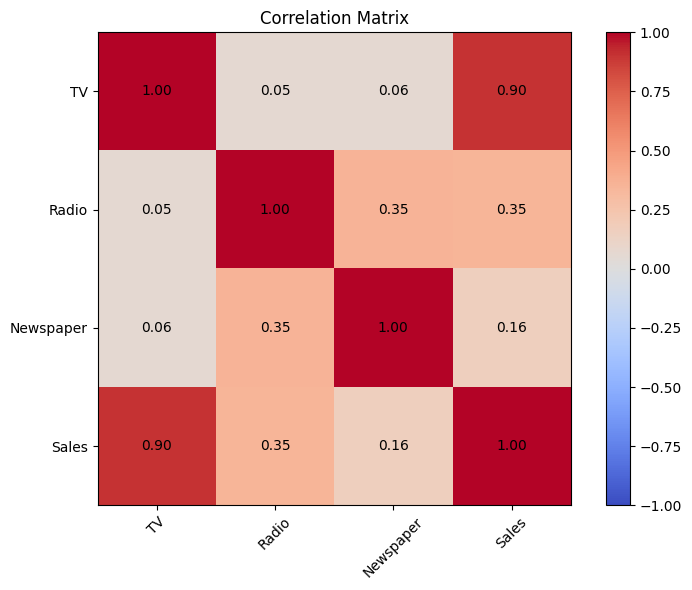

In [9]:
# Calcul de la matrice de corrélation
corr = df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

# Ajouter les labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Ajouter les valeurs dans les cellules
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


L’étude de la corrélation permet de mesurer **la force et le sens de la relation** entre les investissements publicitaires et les ventes.  

#### 🧠 Interprétation
- Les résultats montrent une **forte corrélation positive entre la publicité TV et les ventes**, indiquant que ce canal a un impact important sur les performances commerciales. 

- La publicité Radio présente une **corrélation positive modérée**, suggérant un effet réel mais moins marqué.  

- La publicité Newspaper affiche une **corrélation faible**, ce qui confirme que son influence sur les ventes est limitée.

Cette analyse confirme que **tous les canaux publicitaires n’ont pas le même poids** et justifie l’utilisation d’un modèle de régression linéaire pour quantifier précisément leur impact.